# Лабораторная работа №8. Stable Diffusion

С помощью предобученной модели StableDiffusion сгенерировать фотографии себя в разном окружении (в стиле киберпанка, из металла и тд).
<br>Должно сохраниться ваше лицо!!!
<br>Показать одно качественное изображение и еще 5
<br>Показать изображения, сгенерированные по тексту “<ваш пол> in a forest”, “<ваш пол> in a city”, “<ваш пол> in a beach”, с уточнениями “high quality, realism”
<br>Не использовать трансляцию из изображения в изображение
<br>Не использовать негативные промпты


In [41]:
import torch
from diffusers import StableDiffusionPipeline
from diffusers.schedulers import DPMSolverMultistepScheduler
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Загрузка модели

In [42]:
pipe= StableDiffusionPipeline.from_pretrained(
    "./stable-diffusion-1-5",
    torch_dtype=torch.float16,
    local_files_only=True,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False
).to("cuda")

pipe.scheduler= DPMSolverMultistepScheduler.from_config(pipe.scheduler.config, use_karras_sigmas=True)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: ./stable-diffusion-1-5/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загрузка фотографии

In [43]:
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="models",
    weight_name="ip-adapter-plus-face_sd15.safetensors"
)

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [44]:
my_img=Image.open("my_face.jpg")
my_img = ImageOps.exif_transpose(my_img)
my_img = my_img.resize((512,512))

pipe.set_ip_adapter_scale(0.6)

Промты

In [45]:
my_prompts = [
    "man in a cyberpunk neon city, futuristic clothes, rainy night, cinematic lighting, masterpiece, high quality, realism",
    "man made of liquid metal, T-1000 style, smooth metallic surface, reflections, high quality, realism",
    "man as a galactic emperor, white and gold rich cloack, space station background, high quality, realism",
    "man in a classic noir detective outfit, young, 1940s street, dramatic shadows, high quality, realism",
    "man as a viking warrior, fur cloak, snowy mountains, battle paint, high quality, realism",
    "man in a high-tech laboratory, holographic displays, science fiction, high quality, realism",
]

gen_prompts = [
    "man in a forest, high quality, realism",
    "man in a city, high quality, realism",
    "man at a beach, Hawaii shirt, high quality, realism",
    "quokka in a beach, high quality, realism"
]

Генерация изображения с моим лицом

man in a cyberpunk neon city, futuristic clothes, rainy night, cinematic lighting, masterpiece, high quality, realism


  0%|          | 0/70 [00:00<?, ?it/s]

man made of liquid metal, T-1000 style, smooth metallic surface, reflections, high quality, realism


  0%|          | 0/70 [00:00<?, ?it/s]

man as a galactic emperor, white and gold rich cloack, space station background, high quality, realism


...

  0%|          | 0/70 [00:00<?, ?it/s]

man as a viking warrior, fur cloak, snowy mountains, battle paint, high quality, realism


  0%|          | 0/70 [00:00<?, ?it/s]

man in a high-tech laboratory, holographic displays, science fiction, high quality, realism


  0%|          | 0/70 [00:00<?, ?it/s]

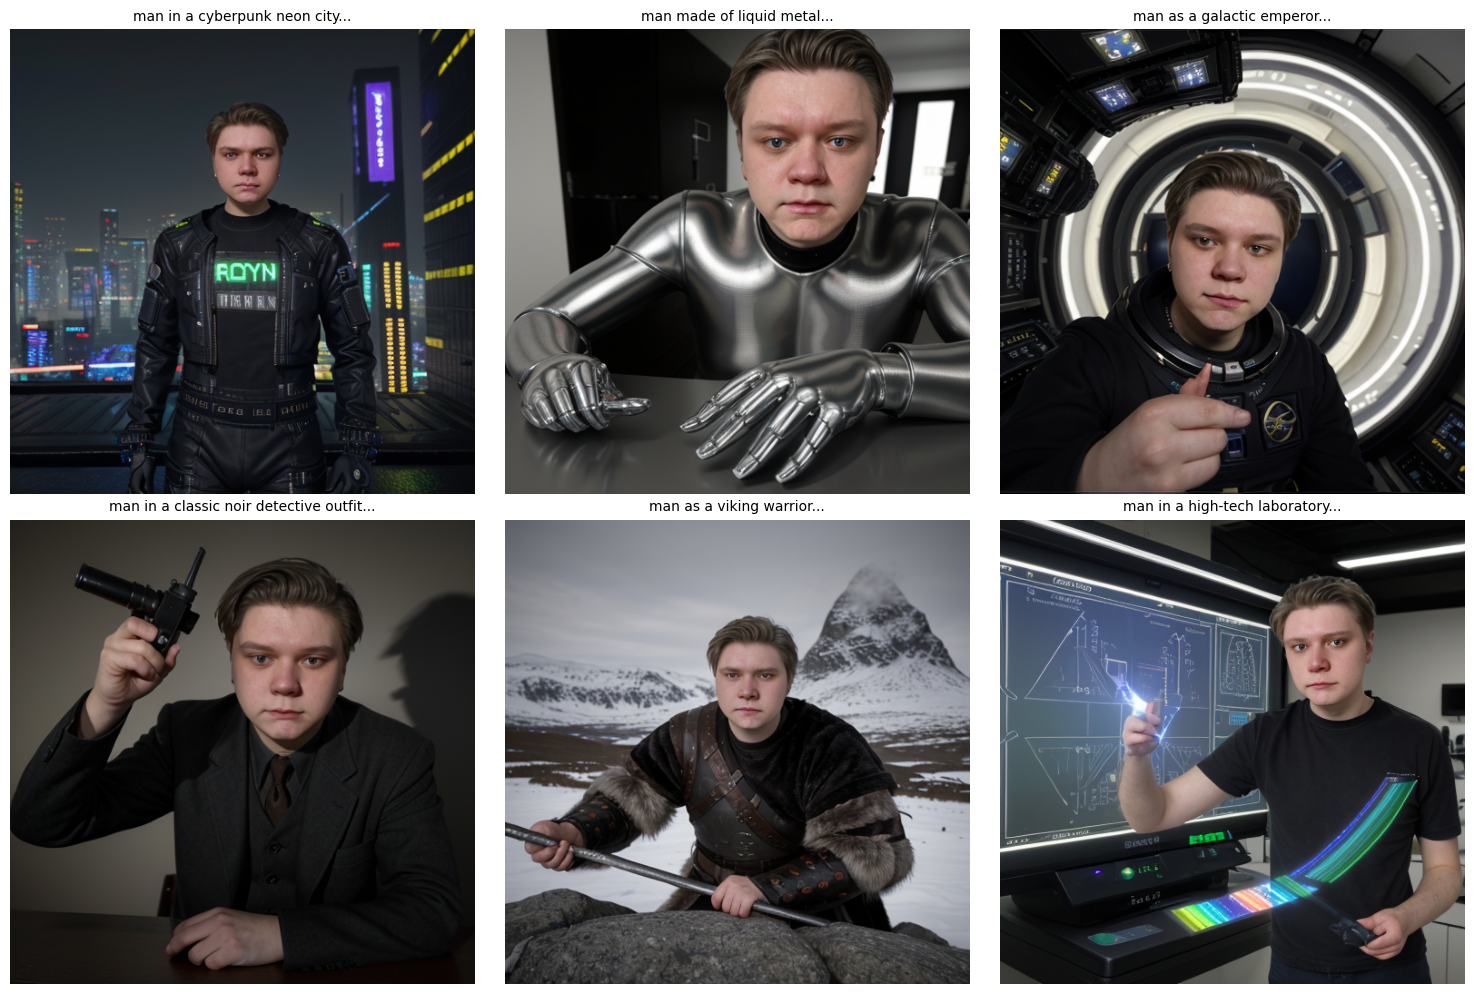

In [46]:
imgs = []

for p in my_prompts:
    print(f"{p}")

    image = pipe(
        prompt=p,
        ip_adapter_image=my_img,
        strenth=0.75,
        num_inference_steps=70,
        guidance_scale=6
    ).images[0]
    imgs.append((image, p))

pipe.unload_ip_adapter()

fig,axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for (img, p), ax in zip(imgs, axes):
    ax.imshow(img)
    ax.axis("off")
    short_title = p.split(",")[0][:40] + "..."
    ax.set_title(short_title, fontsize=10)

plt.tight_layout()
plt.show()

Генерация случайных изображений

man in a forest, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

man in a city, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

man at a beach, Hawaii shirt, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

quokka in a beach, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

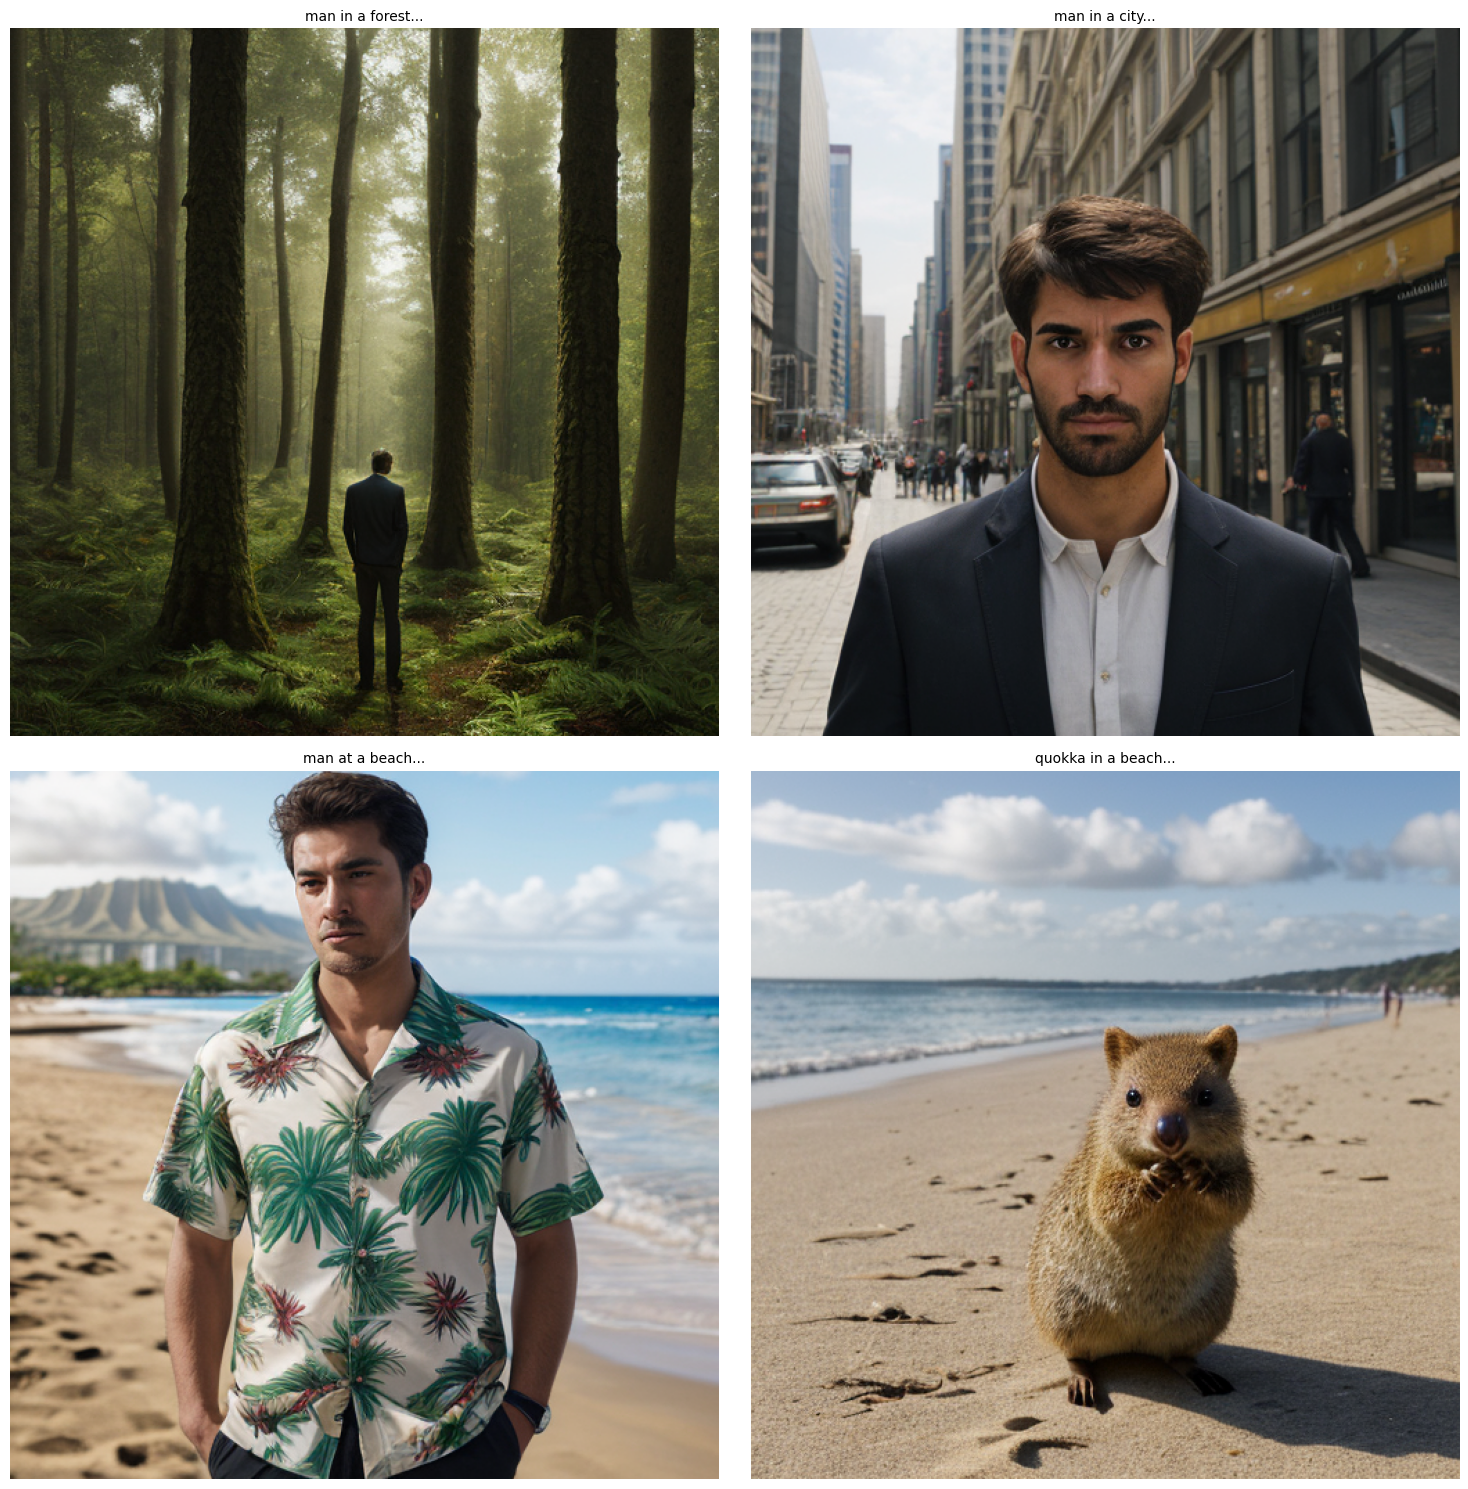

In [47]:
imgs = []

for p in gen_prompts:
    print(f"{p}")
    image = pipe(
        prompt=p,
        num_inference_steps=50,
        guidance_scale=5
    ).images[0]
    imgs.append((image, p))

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

for (img, p), ax in zip(imgs, axes):
    ax.imshow(img)
    ax.axis("off")
    short_title = p.split(",")[0][:40] + "..."
    ax.set_title(short_title, fontsize=10)

plt.tight_layout()
plt.show()